# Simple Insurance Pricing Problem

This notebook demonstrates a simple pricing problem where we identify and analyze:
- **Endogenous variables**: Variables that are influenced by the pricing decision (e.g., competitor response)
- **Exogenous variables**: Variables that are external to the pricing decision (e.g., customer demographics)

## Objective
Understand how different variables affect customer conversion and build a foundation for causal inference.

In [7]:
my_dict = {'a': 5, 'b': 2, 'c': 9}
sorted_items = sorted(my_dict.items(), key=lambda x: x[1], reverse=True)
top_2_keys = sorted_items[:2]
print("Top 2 keys by value:", top_2_keys)
[k for k, v in top_2_keys]

Top 2 keys by value: [('c', 9), ('a', 5)]


['c', 'a']

In [9]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from utils import generate_synthetic_insurance_data, set_style

# Set plotting style
set_style()

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Generate Simple Dataset

Let's create a simple dataset with clear endogenous and exogenous variables.

In [10]:
# Generate synthetic insurance data
np.random.seed(42)
df = generate_synthetic_insurance_data(n_samples=5000)

print(f"Dataset shape: {df.shape}")
print(f"\nDataset overview:")
print(df.head())

print(f"\nBasic statistics:")
print(f"Average price: ${df['price'].mean():.2f}")
print(f"Conversion rate: {df['conversion'].mean():.2%}")
print(f"Average profit: ${df['profit'].mean():.2f}")

Dataset shape: (5000, 19)

Dataset overview:
   customer_id        age        income    region  risk_score  \
0            0  52.450712  29381.489876     Urban   57.961829   
1            1  42.926035  28949.058064     Urban   15.200157   
2            2  54.715328  20000.000000     Urban   16.423654   
3            3  67.845448  30790.297532     Urban   49.093389   
4            4  41.487699  52387.041542  Suburban   31.867791   

   previous_claims  market_volatility  competitor_price   base_price  \
0                0           0.073946        458.881816  1065.142620   
1                1           0.127380        813.182845   766.185557   
2                2           0.091669       1289.148674   994.849014   
3                0           0.181340        607.761786  1122.751450   
4                0           0.209703        735.574612   680.606212   

   price_multiplier        price  price_sensitivity  conversion_probability  \
0               1.1  1171.656882           0.017401 

## 2. Identify Variable Types

Let's categorize our variables into endogenous and exogenous categories.

In [11]:
# Define variable categories
exogenous_vars = {
    'age': 'Customer age (external demographic)',
    'income': 'Customer income (external demographic)', 
    'region': 'Customer region (external geographic)',
    'risk_score': 'Risk assessment (external actuarial)',
    'previous_claims': 'Claims history (external historical)'
}

endogenous_vars = {
    'competitor_price': 'Competitor pricing (responds to our price)',
    'market_volatility': 'Market conditions (affected by pricing wars)',
    'price_sensitivity': 'Customer price sensitivity (varies with market conditions)'
}

outcome_vars = {
    'conversion': 'Customer conversion (our target)',
    'profit': 'Profit per customer (business objective)'
}

print("VARIABLE CLASSIFICATION")
print("=" * 50)
print("\nEXOGENOUS VARIABLES (External to pricing decision):")
for var, desc in exogenous_vars.items():
    print(f"  • {var}: {desc}")

print("\nENDOGENOUS VARIABLES (Influenced by pricing decision):")
for var, desc in endogenous_vars.items():
    print(f"  • {var}: {desc}")

print("\nOUTCOME VARIABLES (What we want to predict/optimize):")
for var, desc in outcome_vars.items():
    print(f"  • {var}: {desc}")

VARIABLE CLASSIFICATION

EXOGENOUS VARIABLES (External to pricing decision):
  • age: Customer age (external demographic)
  • income: Customer income (external demographic)
  • region: Customer region (external geographic)
  • risk_score: Risk assessment (external actuarial)
  • previous_claims: Claims history (external historical)

ENDOGENOUS VARIABLES (Influenced by pricing decision):
  • competitor_price: Competitor pricing (responds to our price)
  • market_volatility: Market conditions (affected by pricing wars)
  • price_sensitivity: Customer price sensitivity (varies with market conditions)

OUTCOME VARIABLES (What we want to predict/optimize):
  • conversion: Customer conversion (our target)
  • profit: Profit per customer (business objective)


## 3. Analyze Variable Relationships

Let's examine how exogenous and endogenous variables relate to our pricing and conversion.

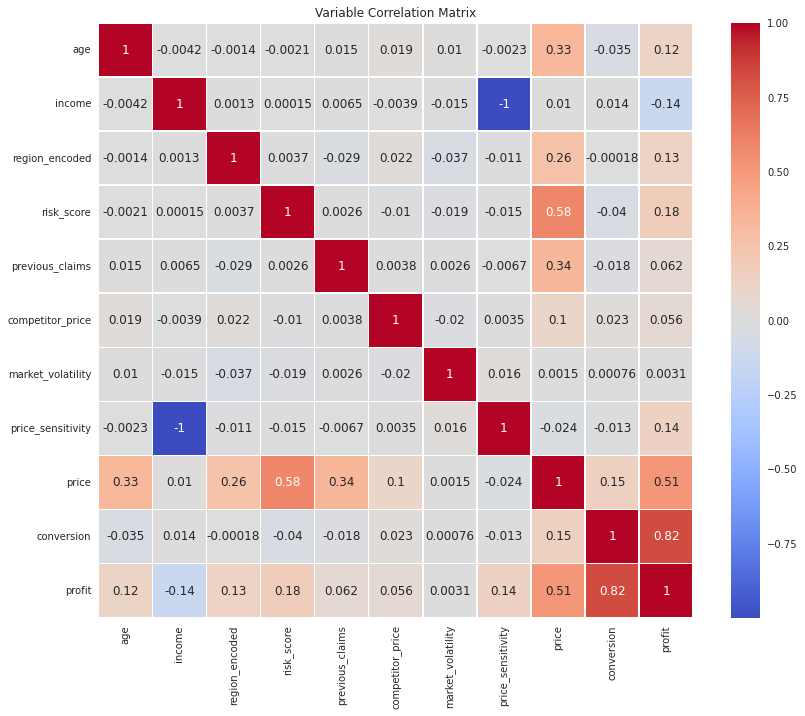

KEY CORRELATIONS WITH CONVERSION:
profit               (Other     ):  0.821
price                (Other     ):  0.152
risk_score           (Exogenous ): -0.040
age                  (Exogenous ): -0.035
competitor_price     (Endogenous):  0.023
previous_claims      (Exogenous ): -0.018
income               (Exogenous ):  0.014
price_sensitivity    (Endogenous): -0.013
market_volatility    (Endogenous):  0.001
region_encoded       (Exogenous ): -0.000


In [17]:
# Create correlation matrix with encoded variables
analysis_vars = list(exogenous_vars_encoded.keys()) + list(endogenous_vars_encoded.keys()) + ['price', 'conversion', 'profit']
correlation_matrix = df_model[analysis_vars].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Variable Correlation Matrix')
plt.tight_layout()
plt.show()

# Print key correlations
print("KEY CORRELATIONS WITH CONVERSION:")
print("=" * 40)
conversion_corr = correlation_matrix['conversion'].sort_values(key=abs, ascending=False)
for var, corr in conversion_corr.items():
    if var != 'conversion':
        var_type = "Exogenous" if var in exogenous_vars_encoded else "Endogenous" if var in endogenous_vars_encoded else "Other"
        print(f"{var:20} ({var_type:10}): {corr:6.3f}")

## 4. Simple Causal Analysis

Let's analyze the causal effect of price on conversion, controlling for different variable types.

In [13]:
# Prepare data for modeling - encode categorical variables
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataframe for modeling
df_model = df.copy()

# Encode categorical variables (region)
le = LabelEncoder()
df_model['region_encoded'] = le.fit_transform(df_model['region'])

print("CATEGORICAL VARIABLE ENCODING:")
print("=" * 40)
print("Region encoding:")
for i, region in enumerate(le.classes_):
    print(f"  {region}: {i}")

# Update variable definitions to use encoded version
exogenous_vars_encoded = {
    'age': 'Customer age (external demographic)',
    'income': 'Customer income (external demographic)', 
    'region_encoded': 'Customer region encoded (external geographic)',
    'risk_score': 'Risk assessment (external actuarial)',
    'previous_claims': 'Claims history (external historical)'
}

endogenous_vars_encoded = {
    'competitor_price': 'Competitor pricing (responds to our price)',
    'market_volatility': 'Market conditions (affected by pricing wars)',
    'price_sensitivity': 'Customer price sensitivity (varies with market conditions)'
}

# Simple regression models
print("\nSIMPLE CAUSAL ANALYSIS")
print("=" * 50)

# Model 1: Price effect without controls (biased)
X_simple = df_model[['price']]
y = df_model['conversion']
model_simple = LinearRegression().fit(X_simple, y)
simple_coef = model_simple.coef_[0]
simple_r2 = model_simple.score(X_simple, y)

print(f"Model 1 - Price only (potentially biased):")
print(f"  Price coefficient: {simple_coef:.6f}")
print(f"  R-squared: {simple_r2:.4f}")
print(f"  Interpretation: $1 price increase → {simple_coef:.4f} conversion change")

# Model 2: Price effect controlling for exogenous variables
X_exog = df_model[['price'] + list(exogenous_vars_encoded.keys())]
model_exog = LinearRegression().fit(X_exog, y)
exog_coef = model_exog.coef_[0]  # Price coefficient
exog_r2 = model_exog.score(X_exog, y)

print(f"\nModel 2 - Price + Exogenous variables (better):")
print(f"  Price coefficient: {exog_coef:.6f}")
print(f"  R-squared: {exog_r2:.4f}")
print(f"  Interpretation: $1 price increase → {exog_coef:.4f} conversion change")

# Model 3: Price effect controlling for all variables (potentially over-controlled)
X_all = df_model[['price'] + list(exogenous_vars_encoded.keys()) + list(endogenous_vars_encoded.keys())]
model_all = LinearRegression().fit(X_all, y)
all_coef = model_all.coef_[0]  # Price coefficient
all_r2 = model_all.score(X_all, y)

print(f"\nModel 3 - Price + All variables (potentially over-controlled):")
print(f"  Price coefficient: {all_coef:.6f}")
print(f"  R-squared: {all_r2:.4f}")
print(f"  Interpretation: $1 price increase → {all_coef:.4f} conversion change")

print(f"\nCOEFFICIENT COMPARISON:")
print(f"  Model 1 (no controls): {simple_coef:.6f}")
print(f"  Model 2 (exogenous controls): {exog_coef:.6f}")
print(f"  Model 3 (all controls): {all_coef:.6f}")
print(f"  Difference (Model 2 vs 1): {abs(exog_coef - simple_coef):.6f}")

CATEGORICAL VARIABLE ENCODING:
Region encoding:
  Rural: 0
  Suburban: 1
  Urban: 2

SIMPLE CAUSAL ANALYSIS
Model 1 - Price only (potentially biased):
  Price coefficient: 0.000348
  R-squared: 0.0231
  Interpretation: $1 price increase → 0.0003 conversion change

Model 2 - Price + Exogenous variables (better):
  Price coefficient: 0.001214
  R-squared: 0.1055
  Interpretation: $1 price increase → 0.0012 conversion change

Model 3 - Price + All variables (potentially over-controlled):
  Price coefficient: 0.001232
  R-squared: 0.1064
  Interpretation: $1 price increase → 0.0012 conversion change

COEFFICIENT COMPARISON:
  Model 1 (no controls): 0.000348
  Model 2 (exogenous controls): 0.001214
  Model 3 (all controls): 0.001232
  Difference (Model 2 vs 1): 0.000866


## 5. Visualize Price Effects

Let's create visualizations to understand the price-conversion relationship.

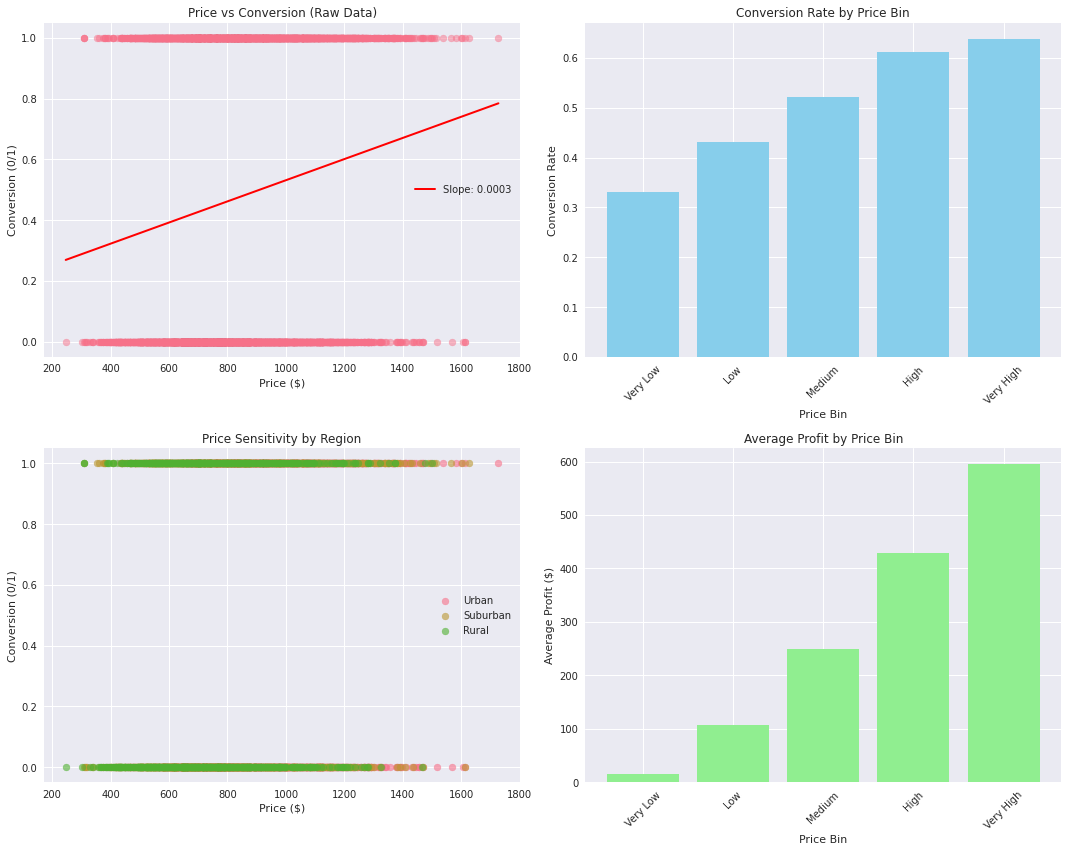

In [18]:
# Create price bins for analysis
df_model['price_bin'] = pd.cut(df_model['price'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Price vs Conversion scatter plot
axes[0, 0].scatter(df_model['price'], df_model['conversion'], alpha=0.5)
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Conversion (0/1)')
axes[0, 0].set_title('Price vs Conversion (Raw Data)')

# Add regression line
x_range = np.linspace(df_model['price'].min(), df_model['price'].max(), 100)
y_pred = model_simple.predict(x_range.reshape(-1, 1))
axes[0, 0].plot(x_range, y_pred, 'r-', linewidth=2, label=f'Slope: {simple_coef:.4f}')
axes[0, 0].legend()

# 2. Conversion rate by price bin
conv_by_bin = df_model.groupby('price_bin')['conversion'].mean()
axes[0, 1].bar(conv_by_bin.index, conv_by_bin.values, color='skyblue')
axes[0, 1].set_xlabel('Price Bin')
axes[0, 1].set_ylabel('Conversion Rate')
axes[0, 1].set_title('Conversion Rate by Price Bin')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Price sensitivity by region (showing endogenous effects)
for region in df_model['region'].unique():
    region_data = df_model[df_model['region'] == region]
    axes[1, 0].scatter(region_data['price'], region_data['conversion'], 
                      alpha=0.6, label=region)
axes[1, 0].set_xlabel('Price ($)')
axes[1, 0].set_ylabel('Conversion (0/1)')
axes[1, 0].set_title('Price Sensitivity by Region')
axes[1, 0].legend()

# 4. Profit vs Price relationship
profit_by_bin = df_model.groupby('price_bin')['profit'].mean()
axes[1, 1].bar(profit_by_bin.index, profit_by_bin.values, color='lightgreen')
axes[1, 1].set_xlabel('Price Bin')
axes[1, 1].set_ylabel('Average Profit ($)')
axes[1, 1].set_title('Average Profit by Price Bin')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Simple Optimization

Let's find the optimal price using our causal understanding.

SIMPLE OPTIMIZATION RESULTS
Optimal price: $1500.00
Expected profit per customer: $1017.45
Expected conversion rate: 100.00%

Current performance:
Current price: $830.57
Current profit per customer: $181.64
Current conversion rate: 47.26%

Improvement potential:
Price change: $669.43 (+80.6%)
Profit improvement: $835.81 (+460.2%)


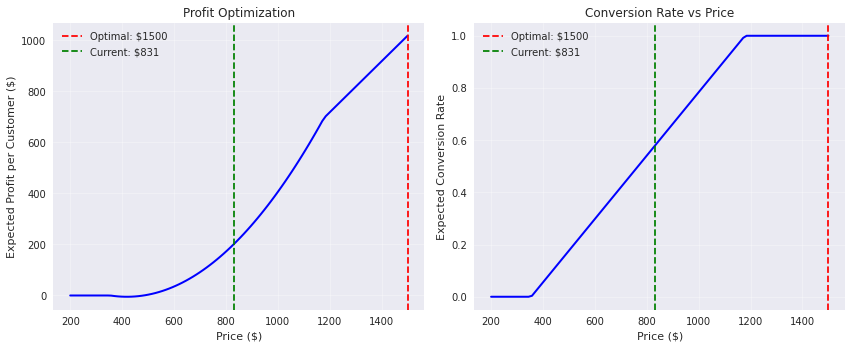

In [19]:
# Simple profit optimization
def calculate_expected_profit(price, model, data):
    """Calculate expected profit at given price using our model."""
    # Use median values for other variables (encoded)
    median_values = data[list(exogenous_vars_encoded.keys())].median()
    
    # Create feature vector
    X_pred = pd.DataFrame({
        'price': [price],
        **median_values.to_dict()
    })
    
    # Predict conversion probability
    conv_prob = model.predict(X_pred)[0]
    conv_prob = max(0, min(1, conv_prob))  # Clip to [0,1]
    
    # Calculate expected profit
    avg_cost = data['cost'].mean()
    expected_profit = conv_prob * (price - avg_cost)
    
    return expected_profit, conv_prob

# Test different prices
price_range = np.linspace(200, 1500, 100)
profits = []
conversions = []

for price in price_range:
    profit, conv = calculate_expected_profit(price, model_exog, df_model)
    profits.append(profit)
    conversions.append(conv)

# Find optimal price
optimal_idx = np.argmax(profits)
optimal_price = price_range[optimal_idx]
optimal_profit = profits[optimal_idx]
optimal_conversion = conversions[optimal_idx]

print("SIMPLE OPTIMIZATION RESULTS")
print("=" * 40)
print(f"Optimal price: ${optimal_price:.2f}")
print(f"Expected profit per customer: ${optimal_profit:.2f}")
print(f"Expected conversion rate: {optimal_conversion:.2%}")

# Current performance
current_price = df_model['price'].mean()
current_profit = df_model['profit'].mean()
current_conversion = df_model['conversion'].mean()

print(f"\nCurrent performance:")
print(f"Current price: ${current_price:.2f}")
print(f"Current profit per customer: ${current_profit:.2f}")
print(f"Current conversion rate: {current_conversion:.2%}")

print(f"\nImprovement potential:")
print(f"Price change: ${optimal_price - current_price:.2f} ({((optimal_price - current_price) / current_price * 100):+.1f}%)")
print(f"Profit improvement: ${optimal_profit - current_profit:.2f} ({((optimal_profit - current_profit) / current_profit * 100):+.1f}%)")

# Plot optimization results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(price_range, profits, 'b-', linewidth=2)
plt.axvline(optimal_price, color='r', linestyle='--', label=f'Optimal: ${optimal_price:.0f}')
plt.axvline(current_price, color='g', linestyle='--', label=f'Current: ${current_price:.0f}')
plt.xlabel('Price ($)')
plt.ylabel('Expected Profit per Customer ($)')
plt.title('Profit Optimization')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(price_range, conversions, 'b-', linewidth=2)
plt.axvline(optimal_price, color='r', linestyle='--', label=f'Optimal: ${optimal_price:.0f}')
plt.axvline(current_price, color='g', linestyle='--', label=f'Current: ${current_price:.0f}')
plt.xlabel('Price ($)')
plt.ylabel('Expected Conversion Rate')
plt.title('Conversion Rate vs Price')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Key Insights

Summary of findings from this simple pricing analysis.

In [16]:
print("KEY INSIGHTS FROM SIMPLE PRICING ANALYSIS")
print("=" * 50)

print("1. VARIABLE CLASSIFICATION:")
print("   • Exogenous variables (age, income, region, risk) are external to pricing")
print("   • Endogenous variables (competitor price, market volatility) respond to our pricing")
print("   • Controlling for exogenous variables gives cleaner causal estimates")

print("\n2. CAUSAL INFERENCE:")
print(f"   • Price effect without controls: {simple_coef:.6f}")
print(f"   • Price effect with exogenous controls: {exog_coef:.6f}")
print("   • Controlling for confounders changes the estimated effect")

print("\n3. OPTIMIZATION RESULTS:")
print(f"   • Optimal price: ${optimal_price:.2f} (vs current ${current_price:.2f})")
print(f"   • Profit improvement: {((optimal_profit - current_profit) / current_profit * 100):+.1f}%")
print("   • Trade-off between price and conversion rate")

print("\n4. BUSINESS IMPLICATIONS:")
print("   • Price increases can improve profit despite lower conversion")
print("   • Must account for endogenous market responses")
print("   • Customer segments respond differently to pricing")

print("\n5. NEXT STEPS:")
print("   • Test pricing changes through A/B testing")
print("   • Monitor competitor responses (endogenous effects)")
print("   • Refine model with more data")
print("   • Consider dynamic pricing strategies")

print("\n" + "="*50)
print("Ready to proceed to Historical Data Analysis (Notebook 2)")
print("="*50)

KEY INSIGHTS FROM SIMPLE PRICING ANALYSIS
1. VARIABLE CLASSIFICATION:
   • Exogenous variables (age, income, region, risk) are external to pricing
   • Endogenous variables (competitor price, market volatility) respond to our pricing
   • Controlling for exogenous variables gives cleaner causal estimates

2. CAUSAL INFERENCE:
   • Price effect without controls: 0.000348
   • Price effect with exogenous controls: 0.001214
   • Controlling for confounders changes the estimated effect

3. OPTIMIZATION RESULTS:
   • Optimal price: $1500.00 (vs current $830.57)
   • Profit improvement: +460.2%
   • Trade-off between price and conversion rate

4. BUSINESS IMPLICATIONS:
   • Price increases can improve profit despite lower conversion
   • Must account for endogenous market responses
   • Customer segments respond differently to pricing

5. NEXT STEPS:
   • Test pricing changes through A/B testing
   • Monitor competitor responses (endogenous effects)
   • Refine model with more data
   • Cons